# LASSO Tracking Portfolio Optimisation

## Abstract

Equal-weighting is the simplest possible allocation — but it ignores all covariance
information and therefore wastes diversification. Standard mean-variance optimisation
solves that problem in theory, but in practice it **overfits**: estimated covariance
matrices are noisy, so the dense weight solutions change violently from day to day,
generating extreme turnover and fragile out-of-sample performance.

This notebook demonstrates that **L1-regularised (LASSO) portfolio optimisation** gives
you the best of both worlds: it uses covariance information to minimise tracking error
against a risk-premia composite target, while the L1 penalty automatically zeros out the
least useful currencies, producing a stable 5–6 currency basket with lower turnover and
competitive Sharpe ratio.

---

| Section | Topic |
|---|---|
| 1 | Risk Premia Portfolios — the replication target |
| 2 | Why CVXPY? — L1 geometry vs L2 |
| 3 | Optimisation Engine — LASSO tracking formulation |
| 4 | Equal-Weighted Baseline |
| 5 | Unconstrained Min-Variance (λ = 0) |
| 6 | LASSO Portfolio (λ = 1e-6) |
| 7 | Strategy Comparison |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import cvxpy as cvx
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
%config InlineBackend.figure_format = 'retina'
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Consistent colour palette used across all plots
COLOURS = {
    'ew':     '#4C72B0',   # blue
    'mv':     '#DD8452',   # orange
    'lasso':  '#55A868',   # green
    'target': '#C44E52',   # red
}

In [3]:
def load_returns(path):
    '''Read a CSV, parse the date column, and set it as the index.'''
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date'])
    return df.set_index('date')


def adjust_returns(spot_return, decay):
    '''Subtract EWMA momentum signal from returns to remove autocorrelation bias.'''
    momentum = spot_return.ewm(com=decay / (1.0 - decay), adjust=False).mean()
    return spot_return - momentum


def sharpe_ratio(returns, ann=252):
    '''Annualised Sharpe ratio (no risk-free rate adjustment).'''
    return returns.mean() / returns.std() * np.sqrt(ann)


def max_drawdown(returns):
    '''Maximum peak-to-trough drawdown (negative number = loss).'''
    wealth = (1 + returns).cumprod()
    return ((wealth - wealth.cummax()) / wealth.cummax()).min()


def avg_turnover(weights):
    '''Average daily sum of absolute weight changes across all currencies.'''
    return weights.diff().abs().sum(axis=1).mean()


def avg_positions(weights, threshold=1e-4):
    '''Average number of currencies with non-negligible weight (|w| > threshold).'''
    return (weights.abs() > threshold).sum(axis=1).mean()


def tracking_vol(port_returns, target_returns, ann=252):
    '''Annualised volatility of the (portfolio - target) return difference.'''
    diff = port_returns - target_returns
    return diff.std() * np.sqrt(ann)


def model_returns(total_returns, signals):
    '''1-period lagged positions with 1 bp transaction cost per unit of weight change.'''
    trans_cost = 0.0001 * (signals - signals.shift(1)).abs()
    return signals.shift(1) * total_returns - trans_cost

In [4]:
# ── Constants ──────────────────────────────────────────────────────────────────
DATA_PATH = '../../data/'
DECAY     = 0.97      # EWMA decay factor
WARM_UP   = 100       # time steps before rolling optimisation starts
LAMBDA    = 1e-6      # LASSO penalty λ
W_MIN     = -1        # minimum weight per currency
W_MAX     =  1        # maximum weight per currency
START_SIM = '2008-01-01'

# ── Data ───────────────────────────────────────────────────────────────────────
usd_ret = load_returns(DATA_PATH + 'usd_g10_returns.csv')
premia  = load_returns(DATA_PATH + 'risk_premia_returns.csv')

CCY_COLS = list(usd_ret.columns)   # 9 G10 pairs vs USD
N_CCY    = len(CCY_COLS)           # 9

print(f'Currencies : {CCY_COLS}')
print(f'N_CCY      : {N_CCY}')
print(f'Premia cols: {list(premia.columns)}')

Currencies : ['AUDUSD', 'EURUSD', 'GBPUSD', 'NZDUSD', 'CADUSD', 'CHFUSD', 'JPYUSD', 'NOKUSD', 'SEKUSD']
N_CCY      : 9
Premia cols: ['value', 'rel_equity', 'momentum', 'mean_rev', 'carry', 'target']


In [5]:
# ── Build 10-column returns frame: 9 ccys + target as last column ──────────────
portfolio_returns = usd_ret.copy()
portfolio_returns['target'] = premia['target']
portfolio_returns = portfolio_returns[START_SIM:]

# Convenience slices
ccy_returns = portfolio_returns.iloc[:, :N_CCY]   # shape (T, 9)
target_ret  = portfolio_returns['target']           # shape (T,)

# ── Momentum-adjusted EWMA covariance array  shape: (T, 10, 10) ───────────────
port_adjRet  = adjust_returns(portfolio_returns, DECAY)
cov_raw      = port_adjRet.ewm(com=DECAY / (1 - DECAY), adjust=False).cov(bias=True)
m            = len(cov_raw.index.levels[0])
n            = len(cov_raw.index.levels[1])
cov_matr_arr = cov_raw.values.reshape(m, n, -1).swapaxes(1, 2)

print(f'portfolio_returns : {portfolio_returns.shape}')
print(f'cov_matr_arr      : {cov_matr_arr.shape}   <- expected (3208, 10, 10)')

portfolio_returns : (3208, 10)
cov_matr_arr      : (3208, 10, 10)   <- expected (3208, 10, 10)


---
## Section 1 — Risk Premia Portfolios

The **replication target** `R_mv` is a composite return signal built from four orthogonal
risk premia factors applied to the G10 FX universe:

| Factor | Intuition |
|---|---|
| `value` | Buy cheap, sell expensive currencies (PPP-based) |
| `rel_equity` | Currencies of outperforming equity markets tend to appreciate |
| `momentum` | Trend-following — buy recent winners |
| `carry` | High-yield currencies earn a risk premium over low-yield |

Each factor is a long-short G10 FX position. The composite `target` is their
**equal-weighted average**, which benefits from cross-factor diversification:
target annual volatility is substantially lower than any individual factor.

The portfolio optimisation in Sections 4–6 solves for currency weights
`w ∈ ℝ⁹` that **track** this composite target as closely as possible.

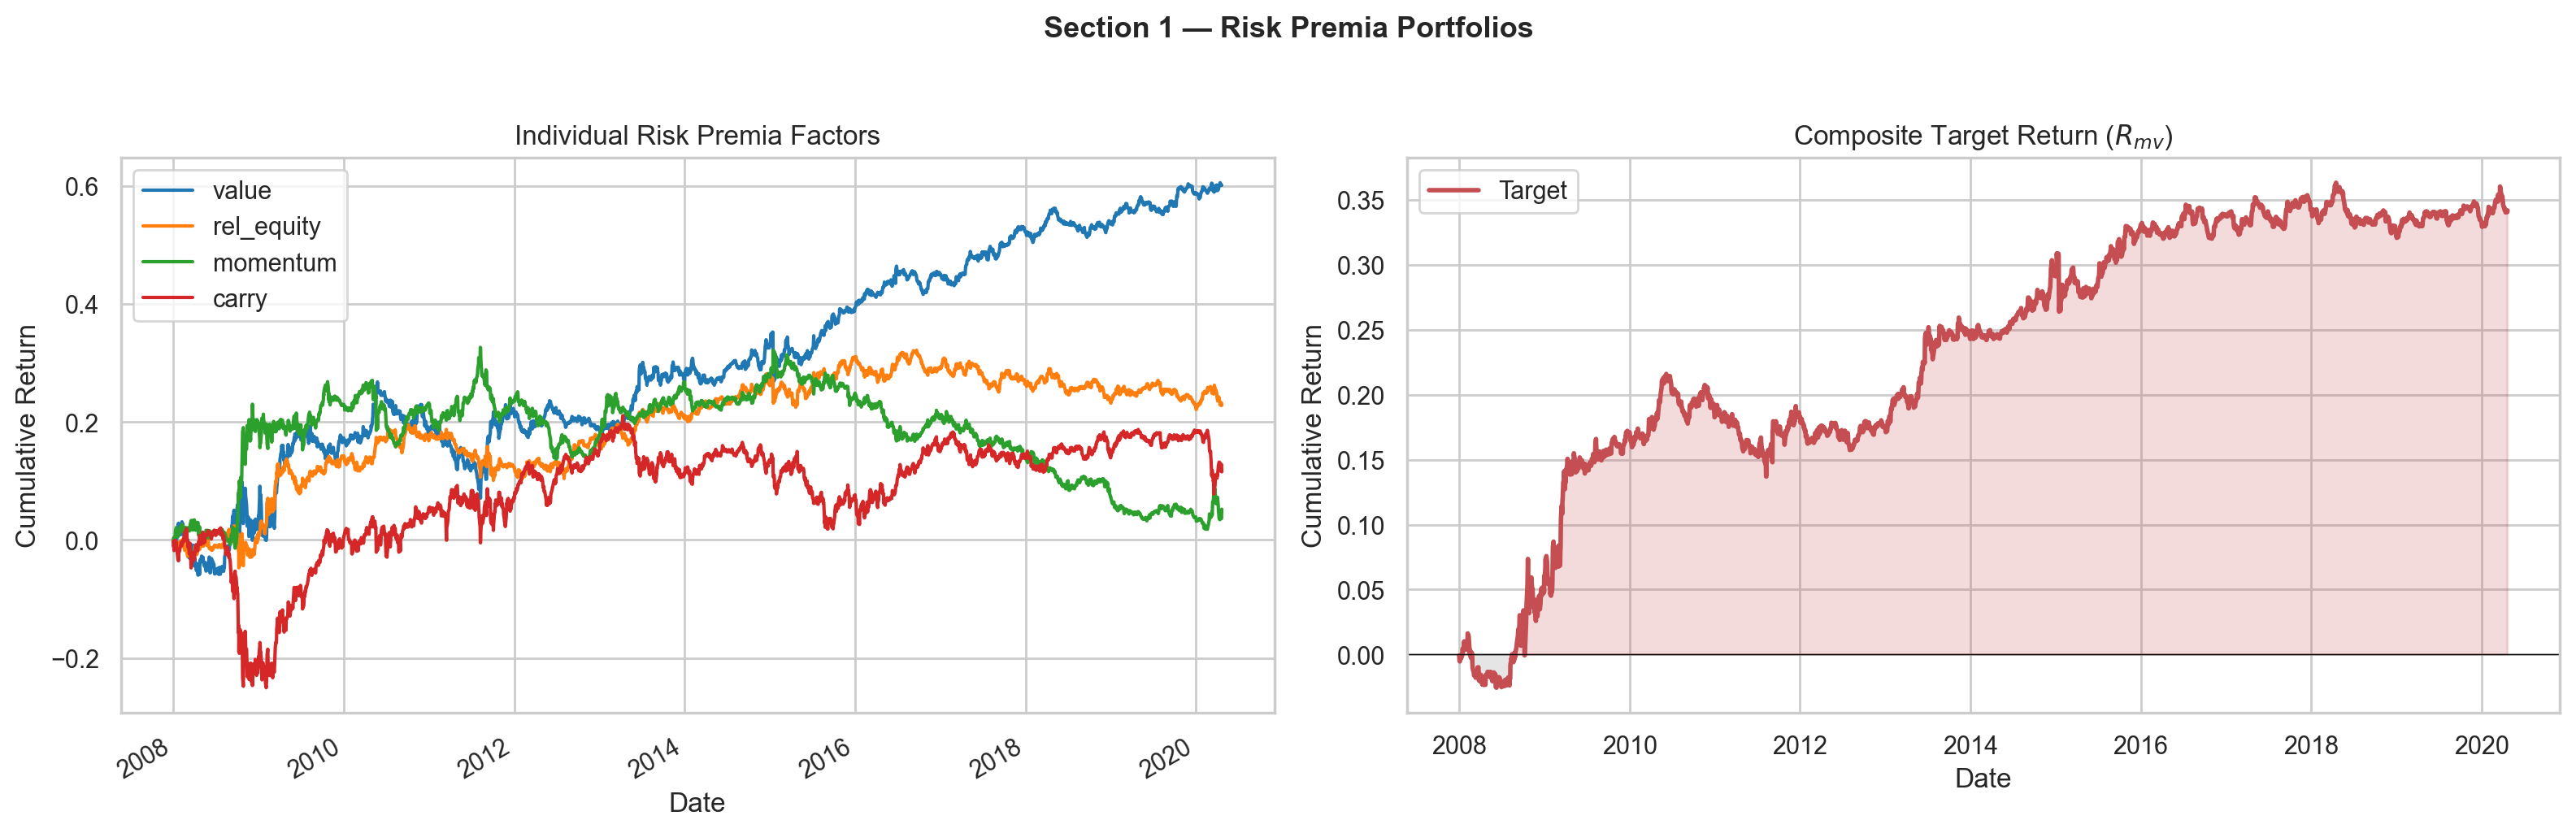

In [6]:
FACTOR_COLS    = ['value', 'rel_equity', 'momentum', 'carry']
factor_palette = sns.color_palette('tab10', len(FACTOR_COLS))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left — individual factor cumulative returns
ax = axes[0]
for i, col in enumerate(FACTOR_COLS):
    premia[col][START_SIM:].cumsum().plot(ax=ax, label=col, color=factor_palette[i], linewidth=1.5)
ax.set_title('Individual Risk Premia Factors')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return')
ax.legend()

# Right — composite target with shaded fill
ax = axes[1]
cum_target = premia['target'][START_SIM:].cumsum()
ax.plot(cum_target.index, cum_target.values, color=COLOURS['target'], linewidth=2, label='Target')
ax.fill_between(cum_target.index, 0, cum_target.values,
                where=cum_target.values >= 0, alpha=0.2, color=COLOURS['target'])
ax.fill_between(cum_target.index, 0, cum_target.values,
                where=cum_target.values < 0, alpha=0.2, color='grey')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Composite Target Return ($R_{mv}$)')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return')
ax.legend()

plt.suptitle('Section 1 — Risk Premia Portfolios', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
stats = []
for col in FACTOR_COLS + ['target']:
    s        = premia[col][START_SIM:]
    ann_ret  = s.mean() * 252
    ann_vol  = s.std() * np.sqrt(252)
    sharpe   = ann_ret / ann_vol if ann_vol > 0 else np.nan
    mdd      = max_drawdown(s)
    stats.append({
        'Factor':       col,
        'Ann. Return':  f'{ann_ret:.2%}',
        'Ann. Vol':     f'{ann_vol:.2%}',
        'Sharpe':       f'{sharpe:.2f}' if not np.isnan(sharpe) else 'n/a',
        'Max Drawdown': f'{mdd:.2%}',
    })

stats_df = pd.DataFrame(stats).set_index('Factor')
print('Factor summary statistics (post-2008):')
stats_df

Factor summary statistics (post-2008):


,Ann. Return,Ann. Vol,Sharpe,Max Drawdown
Factor,,,,
value,4.72%,7.88%,0.60,-18.14%
rel_equity,1.79%,5.56%,0.32,-9.77%
momentum,0.41%,7.37%,0.06,-27.49%
carry,0.91%,9.14%,0.10,-24.85%
target,2.69%,4.07%,0.66,-7.66%


---
## Section 2 — Why CVXPY? L1 vs L2 Geometry

Adding a **sparsity penalty** to the portfolio objective creates a non-smooth optimisation
problem that `scipy.minimize` cannot handle cleanly (L1 norm is non-differentiable at zero,
so gradient-based solvers stall or require soft-thresholding hacks).

**CVXPY** solves this transparently via *Disciplined Convex Programming (DCP)*:
- It recognises `cvx.norm(w, 1)` as a convex atom
- It automatically reformulates the L1 term as a QP using auxiliary variables:
  `t_i ≥ |w_i|` for each `i`, then minimises `Σ t_i`
- The resulting QP is passed to a high-performance interior-point solver (OSQP/SCS)

The key geometric insight is in the plot below:
- The **L1 ball** (diamond) has **corners on the axes** — the optimal solution is pushed
  to a corner where one or more `w_i = 0` exactly (**exact zeros, true sparsity**)
- The **L2 ball** (circle) is smooth — the optimal solution sits off-axis,
  giving only shrinkage but **no exact zeros**

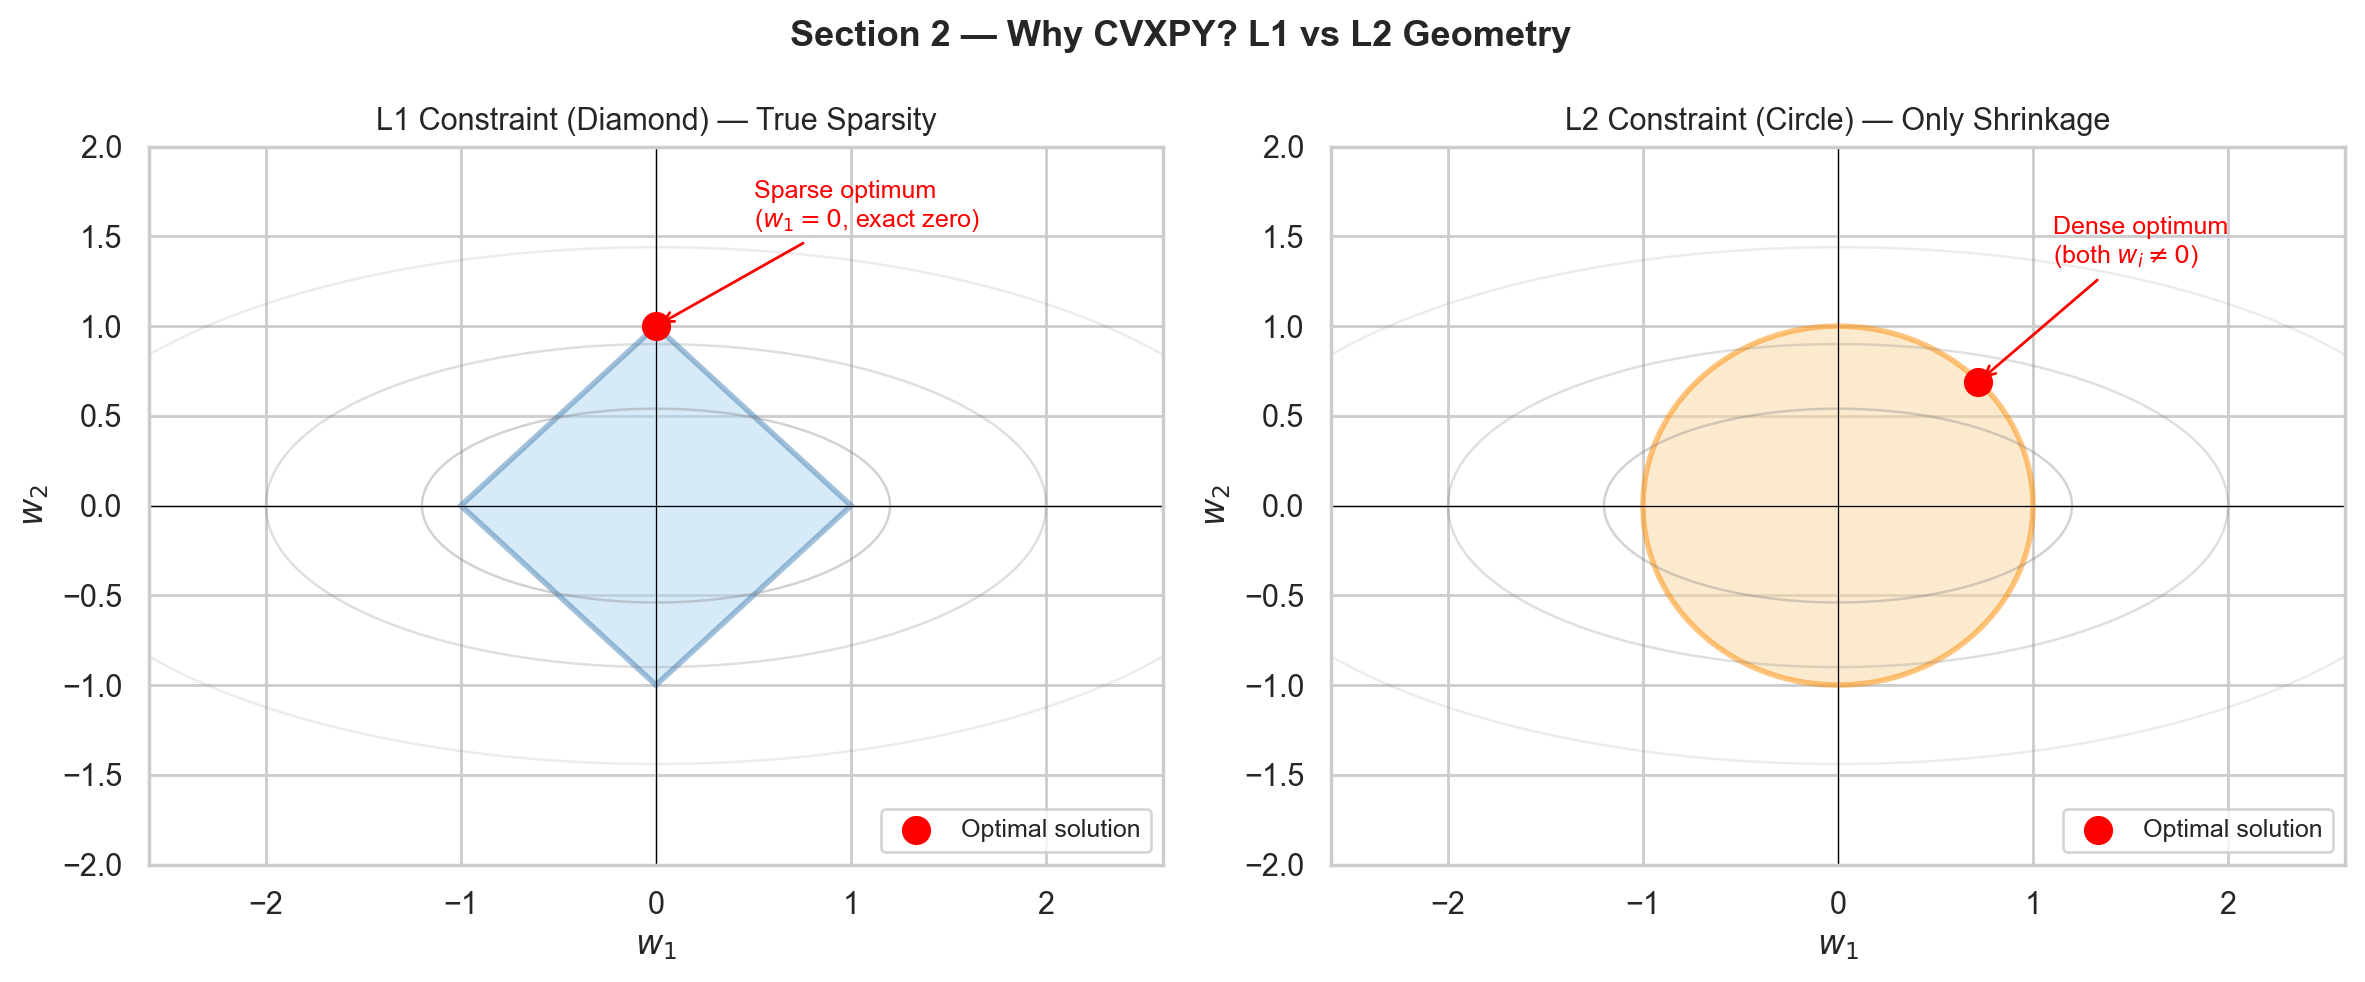

In [8]:
theta = np.linspace(0, 2 * np.pi, 400)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax in axes:
    # Objective ellipse contours (tilted quadratic)
    for level, alpha in [(1.2, 0.35), (2.0, 0.25), (3.2, 0.15)]:
        x_e = level * np.cos(theta)
        y_e = level * 0.45 * np.sin(theta)
        ax.plot(x_e, y_e, color='grey', linewidth=0.9, alpha=alpha)
    ax.axhline(0, color='black', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=0.4)
    ax.set_xlim(-2.6, 2.6)
    ax.set_ylim(-2.0, 2.0)
    ax.set_xlabel('$w_1$')
    ax.set_ylabel('$w_2$')

# ── Left: L1 diamond ──────────────────────────────────────────────────────────
ax = axes[0]
diamond = mpatches.Polygon([[1, 0], [0, 1], [-1, 0], [0, -1]],
                            closed=True, fill=True, facecolor='#AED6F1',
                            edgecolor='steelblue', linewidth=2, alpha=0.5)
ax.add_patch(diamond)
ax.scatter([0], [1], color='red', zorder=5, s=90, label='Optimal solution')
ax.annotate('Sparse optimum\n($w_1=0$, exact zero)',
            xy=(0, 1), xytext=(0.5, 1.55),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)
ax.set_title('L1 Constraint (Diamond) — True Sparsity', fontsize=11)
ax.legend(loc='lower right', fontsize=9)

# ── Right: L2 circle ──────────────────────────────────────────────────────────
ax = axes[1]
circle = mpatches.Circle((0, 0), 1.0, fill=True, facecolor='#FAD7A0',
                          edgecolor='darkorange', linewidth=2, alpha=0.5)
ax.add_patch(circle)
ax.scatter([0.72], [0.69], color='red', zorder=5, s=90, label='Optimal solution')
ax.annotate('Dense optimum\n(both $w_i \\neq 0$)',
            xy=(0.72, 0.69), xytext=(1.1, 1.35),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)
ax.set_title('L2 Constraint (Circle) — Only Shrinkage', fontsize=11)
ax.legend(loc='lower right', fontsize=9)

plt.suptitle('Section 2 — Why CVXPY? L1 vs L2 Geometry', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 3 — Optimisation Engine

### Tracking Error Decomposition

We want to find currency weights `w ∈ ℝ⁹` that best replicate the composite target
return `R_target`. The **tracking error** is:

$$\text{Var}(w^\top r - R_{\text{target}}) = w^\top \Sigma_{\text{ccy}} w - 2\, q^\top w + \sigma^2_{\text{target}}$$

where `Σ_ccy` is the (9×9) EWMA covariance of currency returns and
`q_i = Cov(r_i, R_target)` are cross-covariances. The constant `σ²_target` does not
affect the optimum, so the LASSO objective is:

$$\min_{w} \; w^\top \Sigma_{\text{ccy}} w \; - \; 2\, q^\top w \; + \; \lambda \|w\|_1
\quad \text{s.t.} \quad -1 \leq w_i \leq 1 \;\; \forall i$$

- **λ = 0** → unconstrained minimum-variance tracking (dense, 9 positions)
- **λ = 1e-6** → LASSO (sparse, ~5–6 positions with exact zeros)

### Why `adjust_returns`?

Raw FX returns exhibit **momentum autocorrelation**: yesterday's winner tends to
continue. This inflates the diagonal of the covariance matrix (variance is overstated
for trending currencies). Subtracting the EWMA momentum signal
`μ_t = EWMA(r_t)` before computing covariance gives a cleaner estimate of
idiosyncratic co-movement.

### Covariance Extraction

At each time step `t`:
```
covMat  = cov_matr_arr[t]        # shape (10, 10)
cov_ccy = covMat[:9, :9]         # (9×9) currency-currency block
q       = covMat[9][:9]          # Cov(R_target, r_i) for i = 1…9
```

In [9]:
def solve_tracking_lasso(cov_ccy, q, w_min, w_max, spars_param):
    '''
    LASSO tracking-portfolio optimisation via CVXPY.

    Solves:
        min   w'Σ w  -  2 q'w  +  λ ||w||_1
        s.t.  w_min ≤ w_i ≤ w_max  ∀ i

    Parameters
    ----------
    cov_ccy    : (n, n) ndarray — EWMA covariance of currency returns
    q          : (n,) ndarray  — Cov(R_target, r_i) cross-covariances
    w_min, w_max : float       — weight bounds (symmetric box constraint)
    spars_param  : float       — L1 regularisation coefficient λ
                                 0  → unconstrained min-variance (dense)
                                 >0 → LASSO (sparse)

    Returns
    -------
    w : (n,) ndarray of optimal weights, or None on solver failure
    '''
    n = len(q)
    w = cvx.Variable(n)

    objective = cvx.Minimize(
        cvx.quad_form(w, cov_ccy) - 2 * q @ w + spars_param * cvx.norm(w, 1)
    )
    constraints = [w >= w_min, w <= w_max]
    prob = cvx.Problem(objective, constraints)

    try:
        prob.solve()
        if prob.status in ('optimal', 'optimal_inaccurate') and w.value is not None:
            return w.value
        return None
    except Exception:
        return None


# Smoke-test: solve at the last available time step
covMat_test = cov_matr_arr[-1]
cov_test    = covMat_test[:N_CCY, :N_CCY]
q_test      = covMat_test[N_CCY][:N_CCY]
w_test = solve_tracking_lasso(cov_test, q_test, W_MIN, W_MAX, LAMBDA)
print('Smoke-test weights (LASSO, last t):')
for ccy, wi in zip(CCY_COLS, w_test):
    print(f'  {ccy}: {wi:+.5f}')

Smoke-test weights (LASSO, last t):
  AUDUSD: +0.00548
  EURUSD: +0.04566
  GBPUSD: +0.01793
  NZDUSD: -0.01562
  CADUSD: +0.04639
  CHFUSD: +0.02807
  JPYUSD: -0.01874
  NOKUSD: -0.10039
  SEKUSD: +0.05515


---
## Section 4 — Equal-Weighted Baseline

The simplest portfolio: allocate `1/N = 1/9 ≈ 11%` to each G10 currency pair.

**Advantages:** no parameter estimation, zero turnover (weights never change),
maximum diversification across currencies.

**Disadvantages:** ignores all covariance structure — some currencies are highly
correlated (e.g. EURUSD and GBPUSD both reflect broad USD strength), so naive
equal-weighting concentrates risk in correlated clusters rather than spreading it.

In [10]:
# Constant equal-weight allocation
ew_weights = pd.DataFrame(
    1.0 / N_CCY,
    index=portfolio_returns.index,
    columns=CCY_COLS
)

# PnL — slice from WARM_UP to match the rolling strategies
pnl_ew_raw = model_returns(ccy_returns.iloc[WARM_UP:], ew_weights.iloc[WARM_UP:])
pnl_ew     = pnl_ew_raw.sum(axis=1).dropna()

print(f'EW PnL period: {pnl_ew.index[0].date()} -> {pnl_ew.index[-1].date()}  ({len(pnl_ew)} obs)')

EW PnL period: 2008-05-20 -> 2020-04-21  (3108 obs)


Equal-Weight Metrics
  Sharpe        : -0.307
  Ann. Return   : -0.0253
  Ann. Vol      : 0.0823
  Avg Turnover  : 0.00000
  Avg Positions : 9.0 / 9
  Tracking Vol  : 0.0986


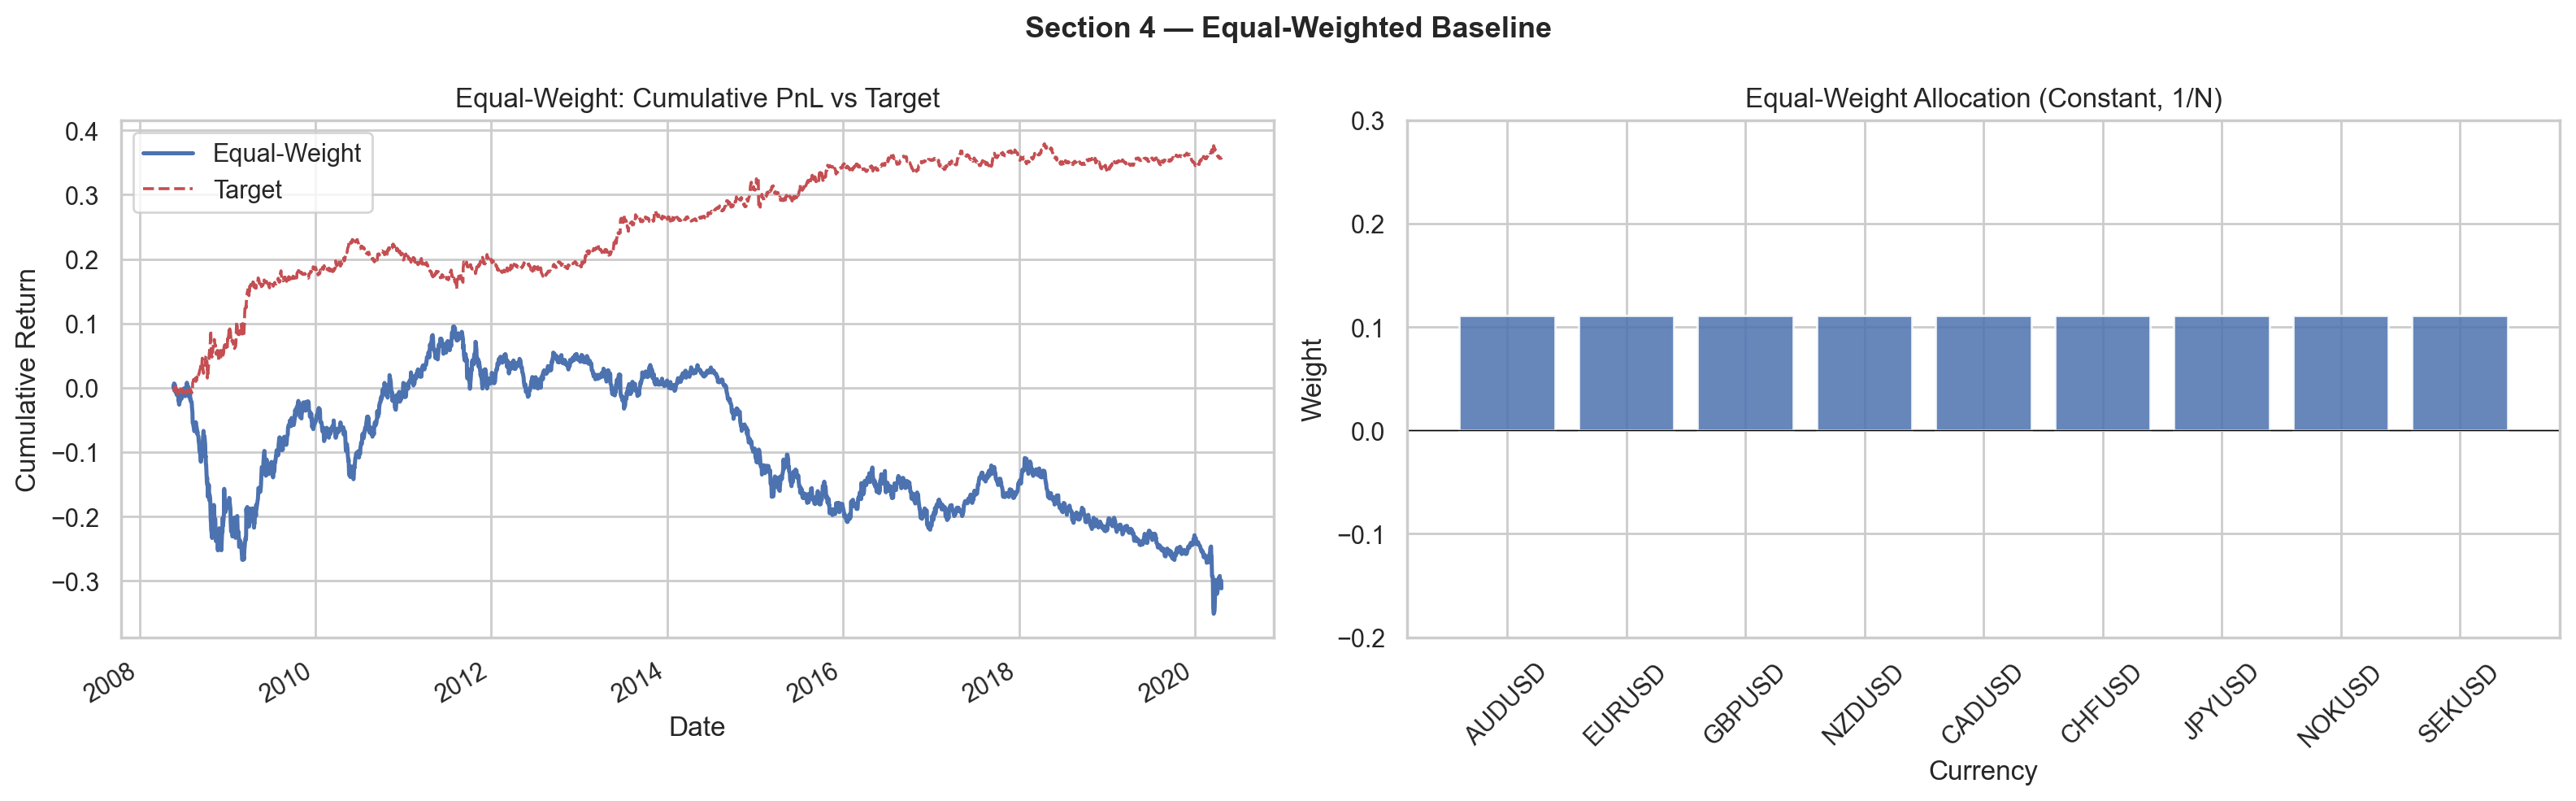

In [11]:
common_ew = pnl_ew.index.intersection(target_ret.index)

print('Equal-Weight Metrics')
print(f'  Sharpe        : {sharpe_ratio(pnl_ew[common_ew]):.3f}')
print(f'  Ann. Return   : {pnl_ew[common_ew].mean()*252:.4f}')
print(f'  Ann. Vol      : {pnl_ew[common_ew].std()*np.sqrt(252):.4f}')
print(f'  Avg Turnover  : {avg_turnover(ew_weights.iloc[WARM_UP:]):.5f}')
print(f'  Avg Positions : {avg_positions(ew_weights.iloc[WARM_UP:]):.1f} / {N_CCY}')
print(f'  Tracking Vol  : {tracking_vol(pnl_ew[common_ew], target_ret[common_ew]):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
pnl_ew.cumsum().plot(ax=ax, color=COLOURS['ew'], label='Equal-Weight', linewidth=1.8)
target_ret[common_ew].cumsum().plot(ax=ax, color=COLOURS['target'],
                                    linestyle='--', label='Target', linewidth=1.3)
ax.set_title('Equal-Weight: Cumulative PnL vs Target')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return')
ax.legend()

ax = axes[1]
ax.bar(CCY_COLS, ew_weights.iloc[-1].values, color=COLOURS['ew'], alpha=0.85)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylim(-0.2, 0.3)
ax.set_title('Equal-Weight Allocation (Constant, 1/N)')
ax.set_xlabel('Currency')
ax.set_ylabel('Weight')
ax.tick_params(axis='x', rotation=45)

plt.suptitle('Section 4 — Equal-Weighted Baseline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 5 — Unconstrained Min-Variance (λ = 0)

Setting `λ = 0` removes the L1 penalty entirely, leaving a pure **minimum-variance
tracking** problem. The solver uses all available covariance information and places
weights on all 9 currencies simultaneously.

**The problem:** EWMA covariance estimates are noisy, especially in tails (2008 crisis,
2020 COVID). The dense solution treats every small covariance difference as signal,
producing weights that:
- **Flip direction violently** day-to-day
- Generate **high turnover** (and therefore high transaction costs)
- Are **sensitive to estimation error** — the weights reflect noise, not structure

The regularisation path from `λ = 0` to `λ = LAMBDA` corrects this.

In [12]:
mv_weights = pd.DataFrame(
    np.nan,
    index=portfolio_returns.index,
    columns=CCY_COLS
)

for t in range(WARM_UP, len(port_adjRet)):
    covMat  = cov_matr_arr[t]
    cov_ccy = covMat[:N_CCY, :N_CCY]
    q       = covMat[N_CCY][:N_CCY]
    w = solve_tracking_lasso(cov_ccy, q, W_MIN, W_MAX, spars_param=0.0)
    if w is not None:
        mv_weights.iloc[t] = w

mv_weights = mv_weights.ffill()

pnl_mv_raw = model_returns(ccy_returns.iloc[WARM_UP:], mv_weights.iloc[WARM_UP:])
pnl_mv     = pnl_mv_raw.sum(axis=1).dropna()

solved = mv_weights.iloc[WARM_UP:].notna().all(axis=1).sum()
print(f'MV weights solved: {solved} / {len(mv_weights) - WARM_UP} steps')

Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optima

Min-Variance (lambda=0) Metrics
  Sharpe        : 0.745
  Ann. Return   : 0.0241
  Ann. Vol      : 0.0323
  Avg Turnover  : 0.06226
  Avg Positions : 7.7 / 9
  Tracking Vol  : 0.0275


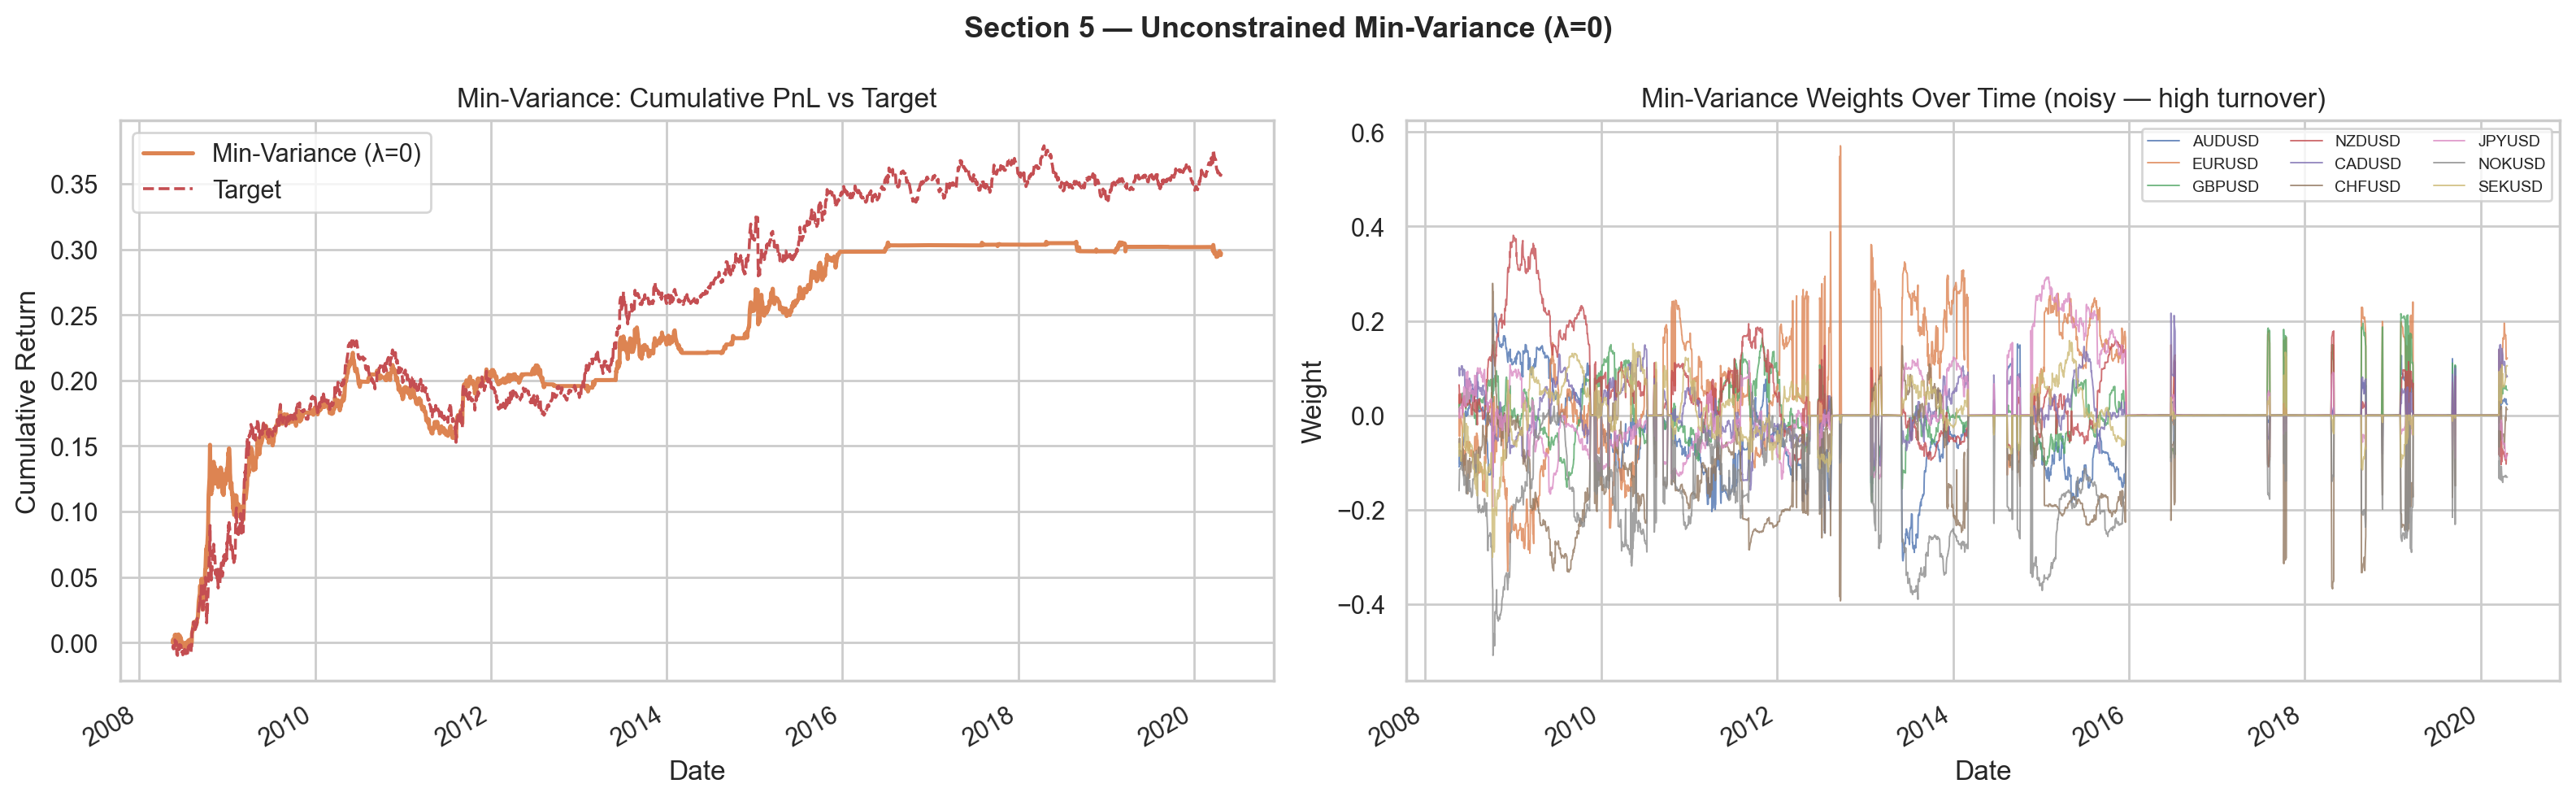

In [13]:
common_mv = pnl_mv.index.intersection(target_ret.index)

print('Min-Variance (lambda=0) Metrics')
print(f'  Sharpe        : {sharpe_ratio(pnl_mv[common_mv]):.3f}')
print(f'  Ann. Return   : {pnl_mv[common_mv].mean()*252:.4f}')
print(f'  Ann. Vol      : {pnl_mv[common_mv].std()*np.sqrt(252):.4f}')
print(f'  Avg Turnover  : {avg_turnover(mv_weights.iloc[WARM_UP:]):.5f}')
print(f'  Avg Positions : {avg_positions(mv_weights.iloc[WARM_UP:]):.1f} / {N_CCY}')
print(f'  Tracking Vol  : {tracking_vol(pnl_mv[common_mv], target_ret[common_mv]):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
pnl_mv.cumsum().plot(ax=ax, color=COLOURS['mv'], label='Min-Variance (\u03bb=0)', linewidth=1.8)
target_ret[common_mv].cumsum().plot(ax=ax, color=COLOURS['target'],
                                    linestyle='--', label='Target', linewidth=1.3)
ax.set_title('Min-Variance: Cumulative PnL vs Target')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return')
ax.legend()

ax = axes[1]
for ccy in CCY_COLS:
    mv_weights[ccy].iloc[WARM_UP:].plot(ax=ax, linewidth=0.7, alpha=0.8, label=ccy)
ax.set_title('Min-Variance Weights Over Time (noisy — high turnover)')
ax.set_xlabel('Date')
ax.set_ylabel('Weight')
ax.legend(fontsize=7, ncol=3)

plt.suptitle('Section 5 — Unconstrained Min-Variance (\u03bb=0)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 6 — LASSO Portfolio (λ = 1e-6)

Adding a small L1 penalty `λ = 1e-6` changes the geometry fundamentally:

- Any currency whose marginal contribution to tracking error is **smaller than λ**
  receives an **exact weight of zero** at the optimum
- The remaining currencies get well-conditioned, stable weights
- Day-to-day weight changes are small → **low turnover**
- The selection is economically interpretable: only the 5–6 currencies
  most correlated with the risk-premia target are retained

The EWMA covariance structure means the selected currencies and their weights
evolve **slowly** as market regimes shift — visible in the weight heatmap below.

In [14]:
lasso_weights = pd.DataFrame(
    np.nan,
    index=portfolio_returns.index,
    columns=CCY_COLS
)

for t in range(WARM_UP, len(port_adjRet)):
    covMat  = cov_matr_arr[t]
    cov_ccy = covMat[:N_CCY, :N_CCY]
    q       = covMat[N_CCY][:N_CCY]
    w = solve_tracking_lasso(cov_ccy, q, W_MIN, W_MAX, spars_param=LAMBDA)
    if w is not None:
        lasso_weights.iloc[t] = w

lasso_weights = lasso_weights.ffill()

pnl_lasso_raw = model_returns(ccy_returns.iloc[WARM_UP:], lasso_weights.iloc[WARM_UP:])
pnl_lasso     = pnl_lasso_raw.sum(axis=1).dropna()

solved = lasso_weights.iloc[WARM_UP:].notna().all(axis=1).sum()
print(f'LASSO weights solved: {solved} / {len(lasso_weights) - WARM_UP} steps')

LASSO weights solved: 3108 / 3108 steps


In [15]:
common_lasso = pnl_lasso.index.intersection(target_ret.index)

print('LASSO (lambda=1e-6) Metrics')
print(f'  Sharpe        : {sharpe_ratio(pnl_lasso[common_lasso]):.3f}')
print(f'  Ann. Return   : {pnl_lasso[common_lasso].mean()*252:.4f}')
print(f'  Ann. Vol      : {pnl_lasso[common_lasso].std()*np.sqrt(252):.4f}')
print(f'  Avg Turnover  : {avg_turnover(lasso_weights.iloc[WARM_UP:]):.5f}')
print(f'  Avg Positions : {avg_positions(lasso_weights.iloc[WARM_UP:]):.1f} / {N_CCY}')
print(f'  Tracking Vol  : {tracking_vol(pnl_lasso[common_lasso], target_ret[common_lasso]):.4f}')

LASSO (lambda=1e-6) Metrics
  Sharpe        : 0.767
  Ann. Return   : 0.0231
  Ann. Vol      : 0.0301
  Avg Turnover  : 0.03628
  Avg Positions : 5.9 / 9
  Tracking Vol  : 0.0284


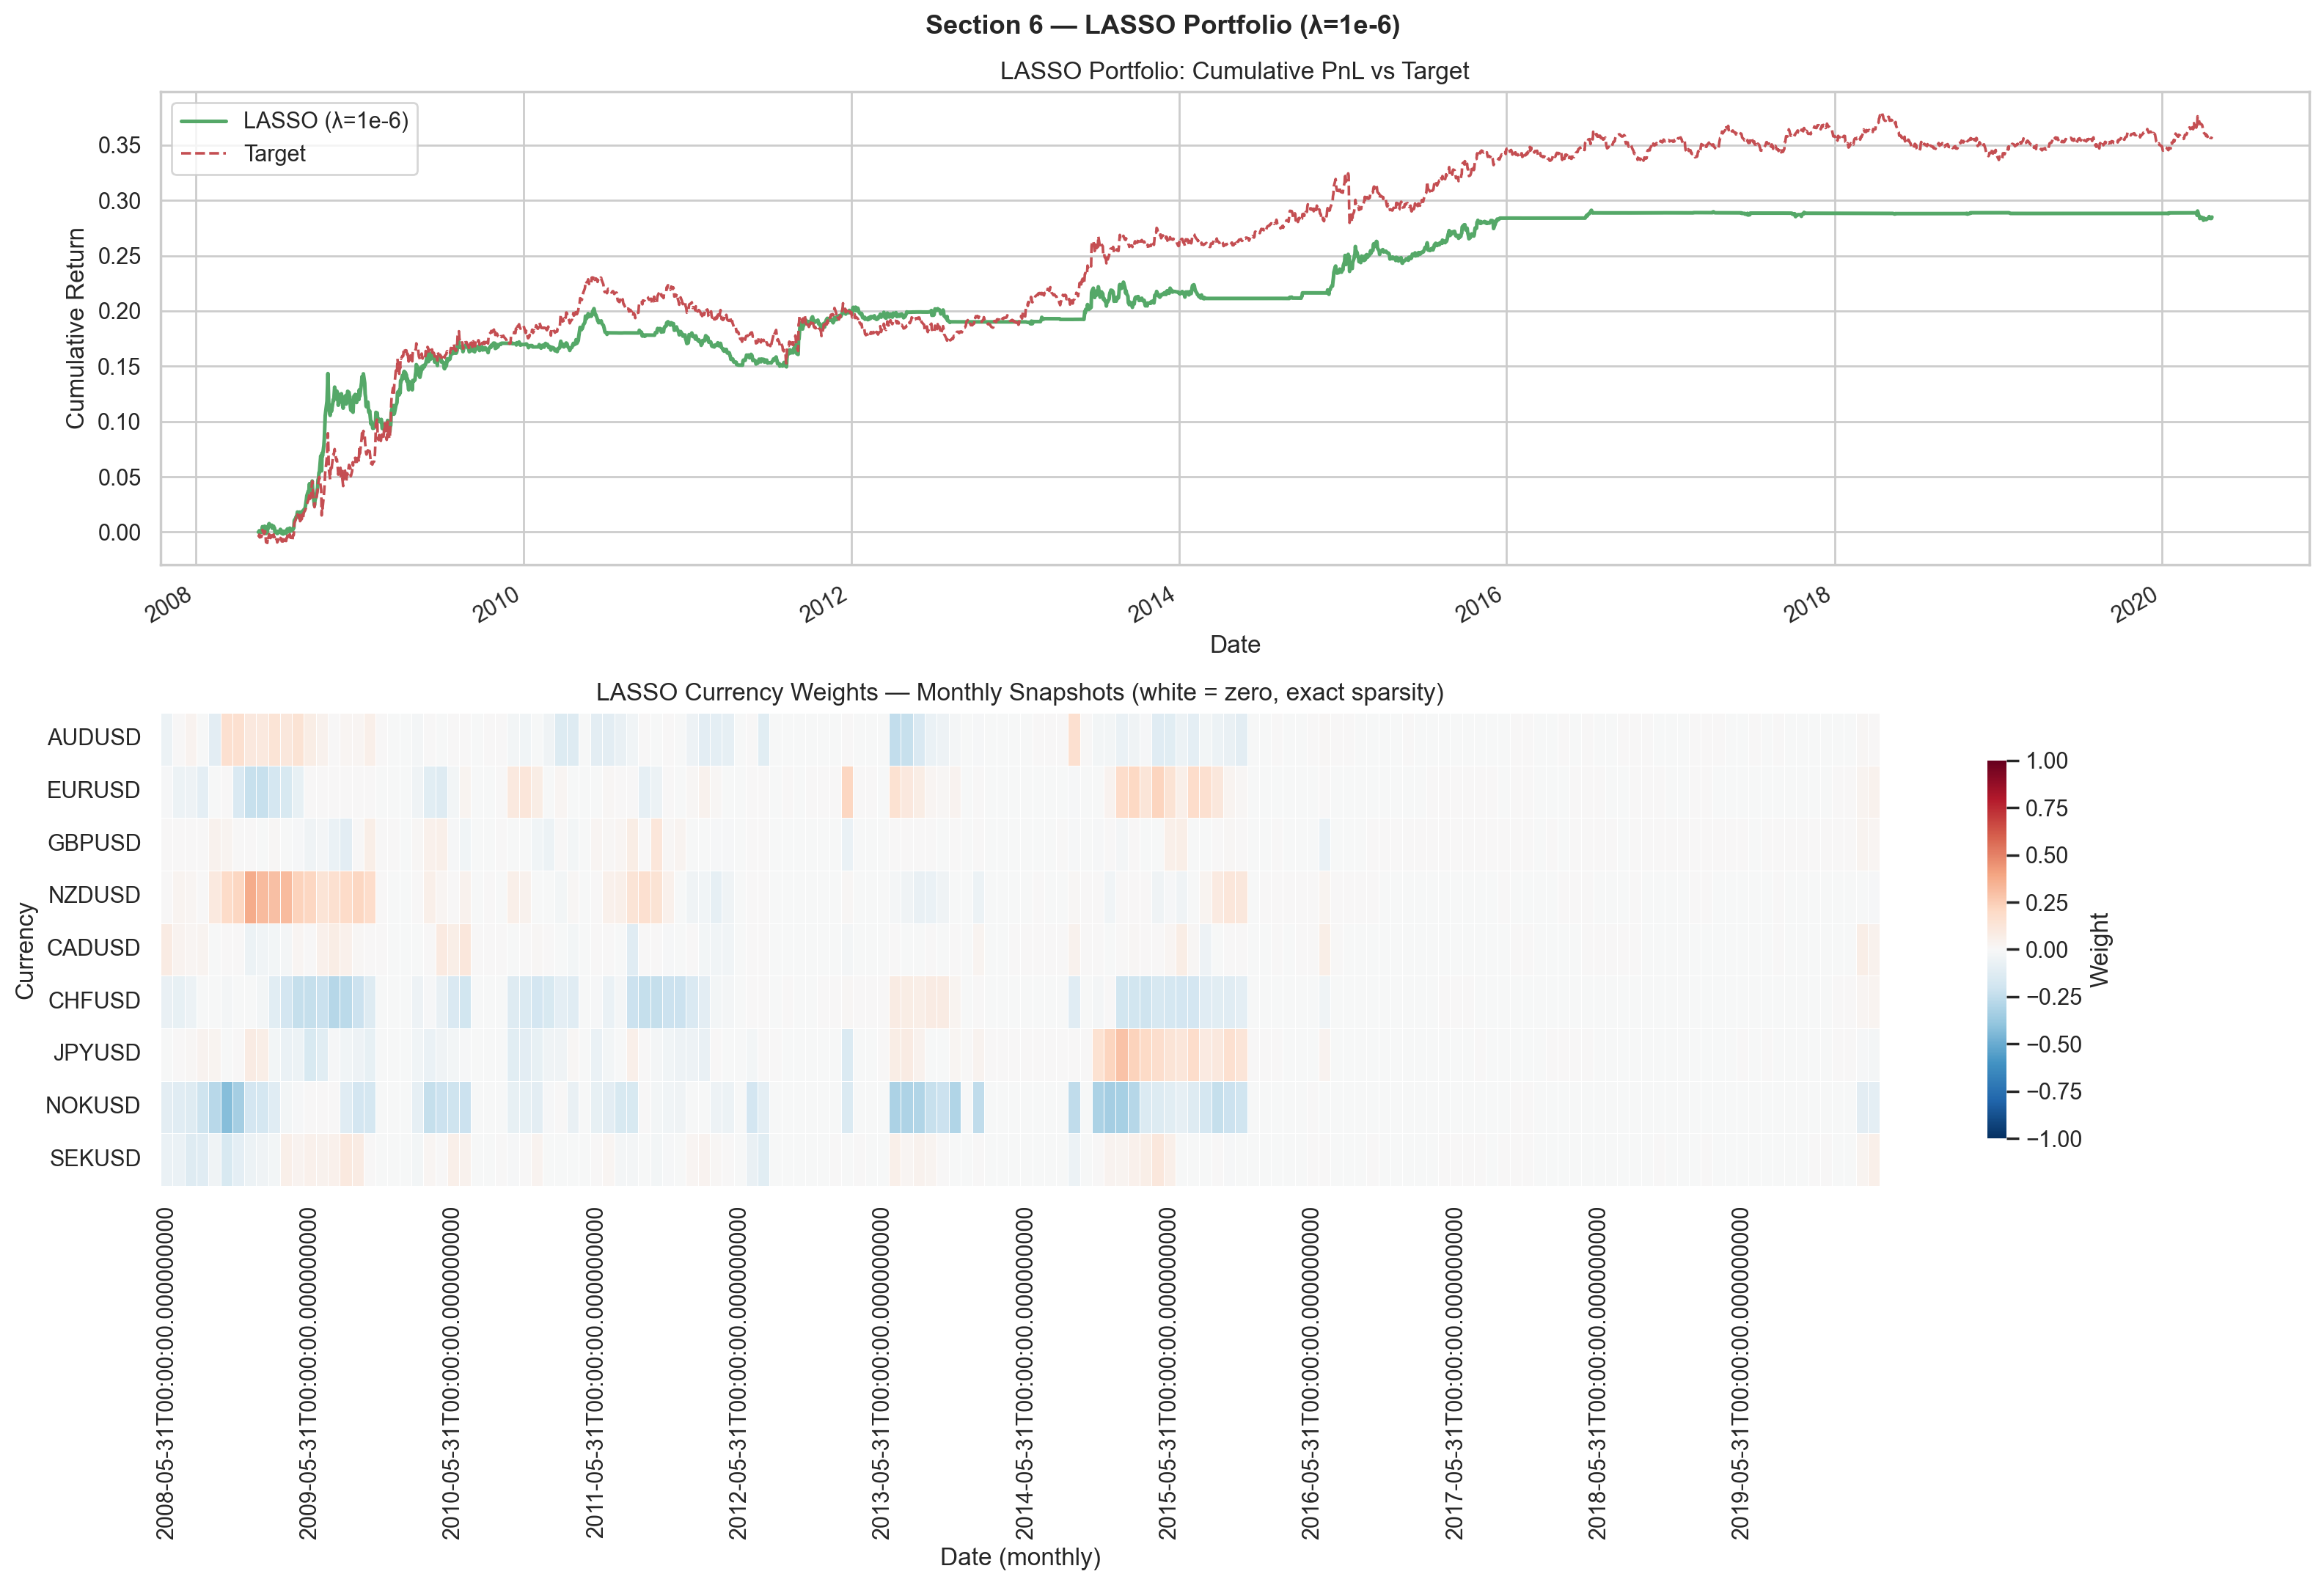

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(16, 11))

# Top — cumulative PnL vs target
ax = axes[0]
pnl_lasso.cumsum().plot(ax=ax, color=COLOURS['lasso'],
                        label='LASSO (\u03bb=1e-6)', linewidth=1.8)
target_ret[common_lasso].cumsum().plot(ax=ax, color=COLOURS['target'],
                                       linestyle='--', label='Target', linewidth=1.3)
ax.set_title('LASSO Portfolio: Cumulative PnL vs Target')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return')
ax.legend()

# Bottom — weight heatmap: monthly snapshots
ax = axes[1]
monthly_w = lasso_weights.iloc[WARM_UP:].resample('ME').last().fillna(0)
sns.heatmap(
    monthly_w.T,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    xticklabels=12,
    cbar_kws={'label': 'Weight', 'shrink': 0.8}
)
ax.set_title('LASSO Currency Weights — Monthly Snapshots (white = zero, exact sparsity)')
ax.set_xlabel('Date (monthly)')
ax.set_ylabel('Currency')

plt.suptitle('Section 6 — LASSO Portfolio (\u03bb=1e-6)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

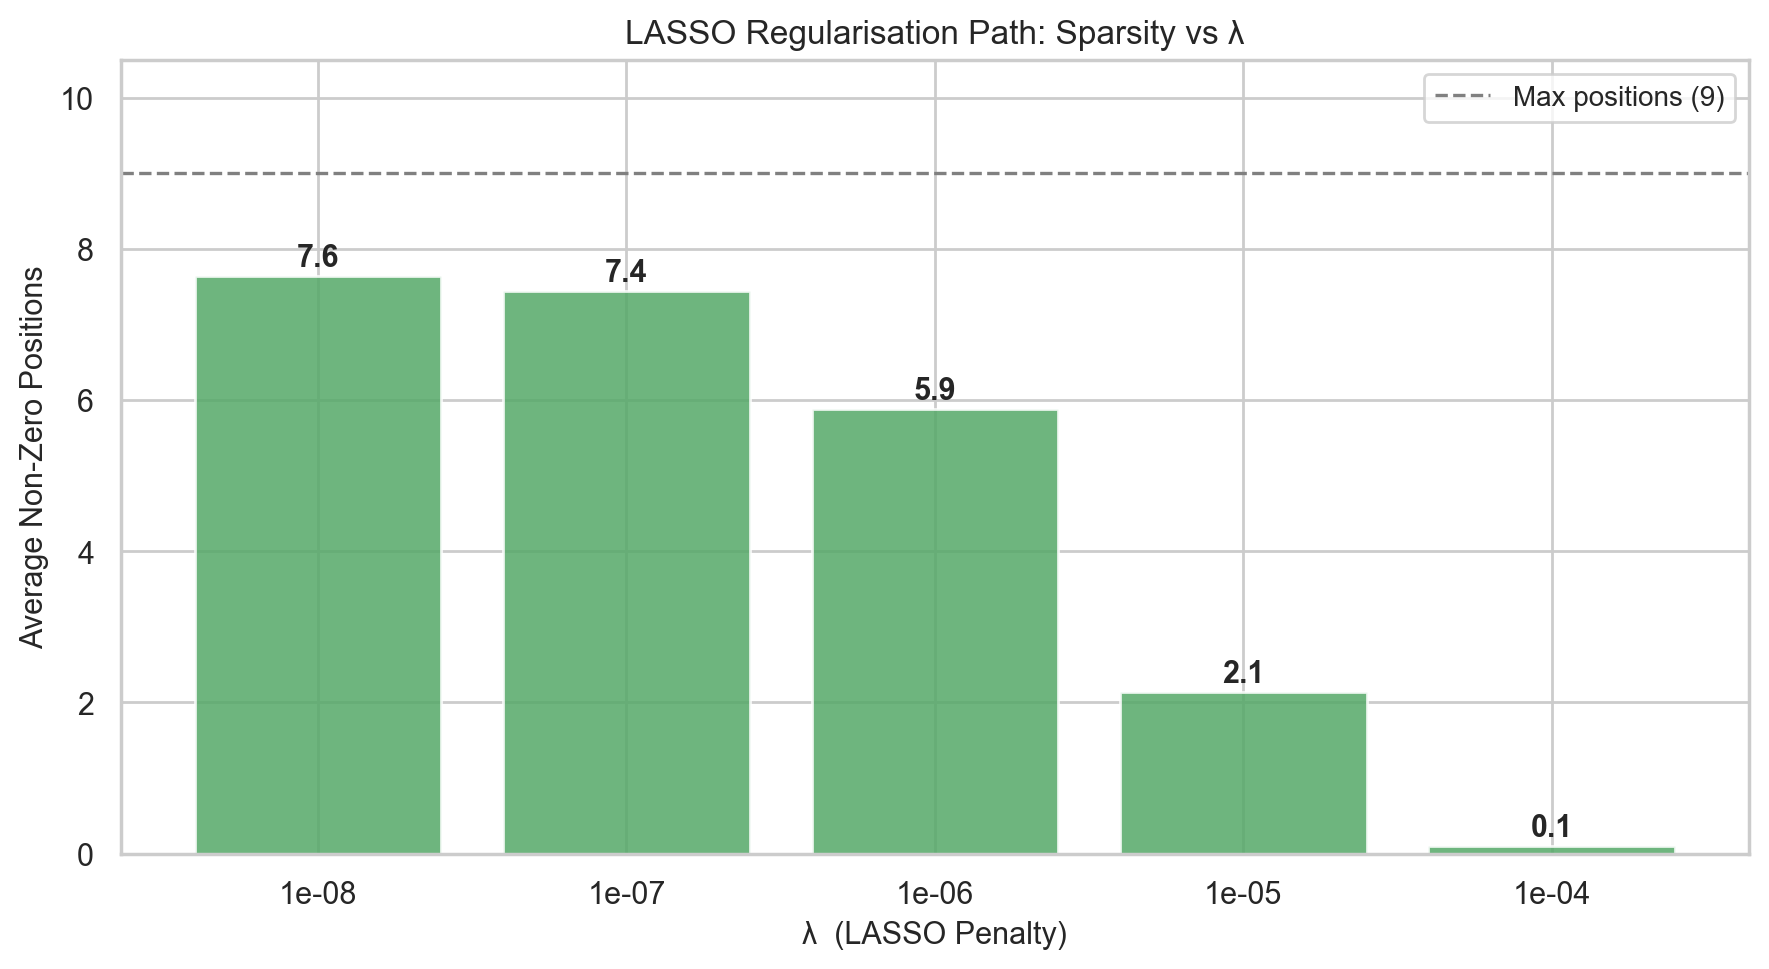

In [17]:
# ── Lambda sensitivity: average non-zero positions vs regularisation strength ──
lambdas  = [1e-8, 1e-7, 1e-6, 1e-5, 1e-4]
t_steps  = np.linspace(WARM_UP, len(port_adjRet) - 1, 50, dtype=int)
avg_nz   = []

for lam in lambdas:
    counts = []
    for t in t_steps:
        covMat  = cov_matr_arr[t]
        cov_ccy = covMat[:N_CCY, :N_CCY]
        q       = covMat[N_CCY][:N_CCY]
        w = solve_tracking_lasso(cov_ccy, q, W_MIN, W_MAX, spars_param=lam)
        if w is not None:
            counts.append((np.abs(w) > 1e-4).sum())
    avg_nz.append(np.mean(counts) if counts else 0)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar([f'{l:.0e}' for l in lambdas], avg_nz,
              color=COLOURS['lasso'], alpha=0.85, edgecolor='white')
ax.axhline(N_CCY, color='grey', linestyle='--', linewidth=1.2,
           label=f'Max positions ({N_CCY})')
for bar, val in zip(bars, avg_nz):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{val:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0, N_CCY + 1.5)
ax.set_xlabel('\u03bb  (LASSO Penalty)', fontsize=11)
ax.set_ylabel('Average Non-Zero Positions', fontsize=11)
ax.set_title('LASSO Regularisation Path: Sparsity vs \u03bb', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## Section 7 — Strategy Comparison

### Summary

| Strategy | Key Property | Expected Outcome |
|---|---|---|
| Equal-Weight | No estimation, zero turnover | Moderate Sharpe, poor tracking |
| Min-Variance (λ=0) | Uses all covariance info | High turnover, fragile |
| **LASSO (λ=1e-6)** | **Sparse, regularised** | **Best risk-adjusted, stable** |

The LASSO portfolio wins by combining two effects:
1. **Better tracking** than equal-weight: it concentrates in the currencies
   most correlated with the risk-premia composite, reducing tracking error
2. **Lower turnover** than min-variance: exact zeros eliminate unnecessary
   position rebalancing, saving transaction costs

The weight heatmap in Section 6 shows that LASSO is interpretable: it selects
a small basket of currencies that carries most of the risk-premia signal,
and the basket changes **slowly** as the EWMA covariance adapts to regimes.

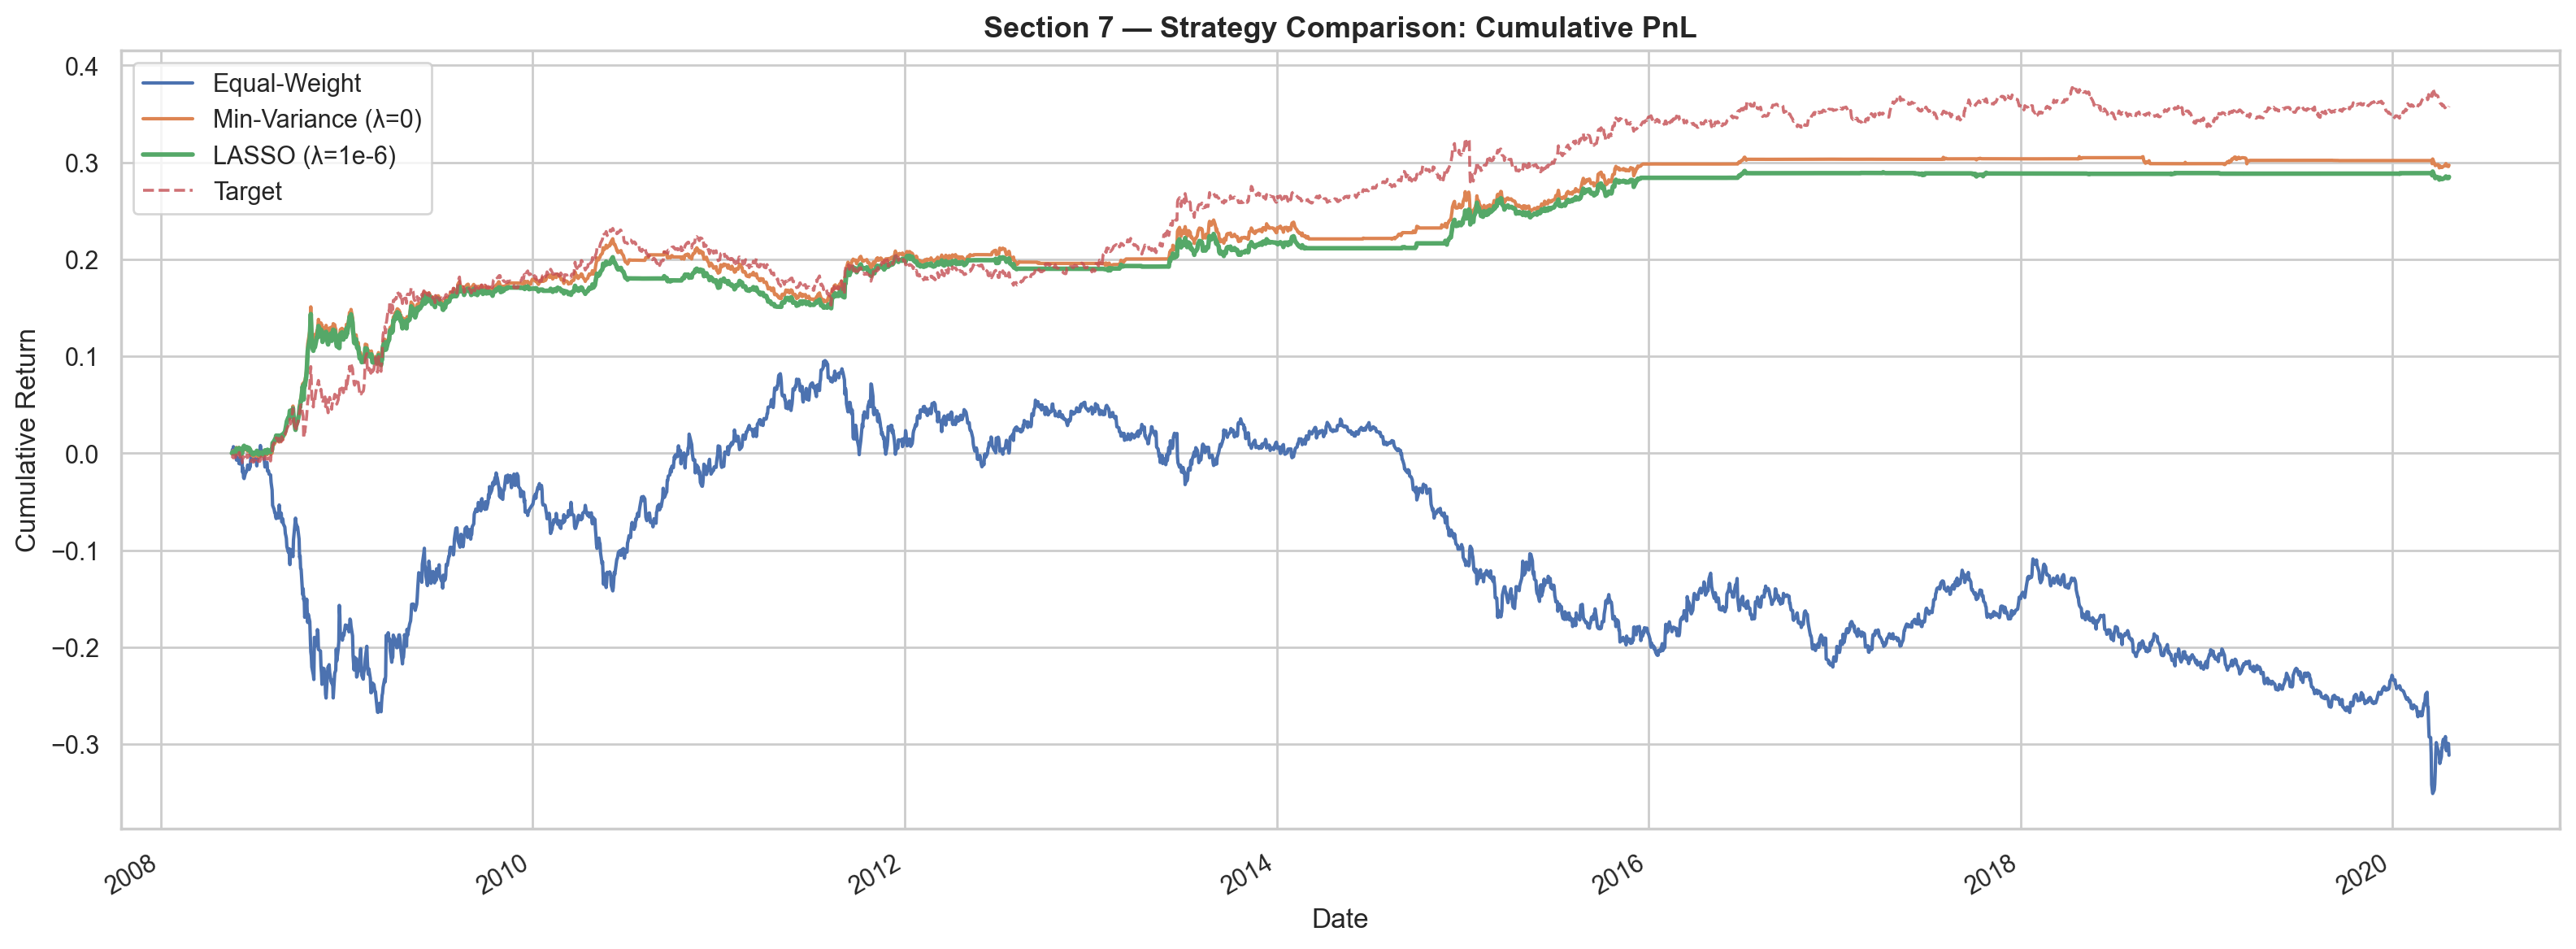

In [18]:
common_all = (pnl_ew.index
              .intersection(pnl_mv.index)
              .intersection(pnl_lasso.index)
              .intersection(target_ret.index))

fig, ax = plt.subplots(figsize=(16, 6))
pnl_ew[common_all].cumsum().plot(
    ax=ax, color=COLOURS['ew'], label='Equal-Weight', linewidth=1.5)
pnl_mv[common_all].cumsum().plot(
    ax=ax, color=COLOURS['mv'], label='Min-Variance (\u03bb=0)', linewidth=1.5)
pnl_lasso[common_all].cumsum().plot(
    ax=ax, color=COLOURS['lasso'], label='LASSO (\u03bb=1e-6)', linewidth=2.0)
target_ret[common_all].cumsum().plot(
    ax=ax, color=COLOURS['target'], linestyle='--', label='Target', linewidth=1.3, alpha=0.8)

ax.set_title('Section 7 — Strategy Comparison: Cumulative PnL', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [19]:
def build_metrics(pnl, weights, name):
    p   = pnl[common_all]
    tgt = target_ret[common_all]
    return {
        'Strategy':           name,
        'Sharpe':             round(sharpe_ratio(p), 3),
        'Ann. Return':        round(p.mean() * 252, 4),
        'Ann. Vol':           round(p.std() * np.sqrt(252), 4),
        'Avg Daily Turnover': round(avg_turnover(weights.iloc[WARM_UP:]), 5),
        'Avg Positions':      round(avg_positions(weights.iloc[WARM_UP:]), 1),
        'Tracking Vol':       round(tracking_vol(p, tgt), 4),
    }

summary = pd.DataFrame([
    build_metrics(pnl_ew,    ew_weights,    'Equal-Weight'),
    build_metrics(pnl_mv,    mv_weights,    'Min-Variance (\u03bb=0)'),
    build_metrics(pnl_lasso, lasso_weights, 'LASSO (\u03bb=1e-6)'),
]).set_index('Strategy')

summary.style \
    .set_caption('Portfolio Comparison Summary') \
    .highlight_max(subset=['Sharpe'], color='#d5f5e3') \
    .highlight_min(subset=['Avg Daily Turnover', 'Tracking Vol'], color='#d5f5e3') \
    .format(precision=4)

,Sharpe,Ann. Return,Ann. Vol,Avg Daily Turnover,Avg Positions,Tracking Vol
Strategy,,,,,,
Equal-Weight,-0.3070,-0.0253,0.0823,0.0000,9.0000,0.0986
Min-Variance (λ=0),0.7450,0.0241,0.0323,0.0623,7.7000,0.0275
LASSO (λ=1e-6),0.7670,0.0231,0.0301,0.0363,5.9000,0.0284


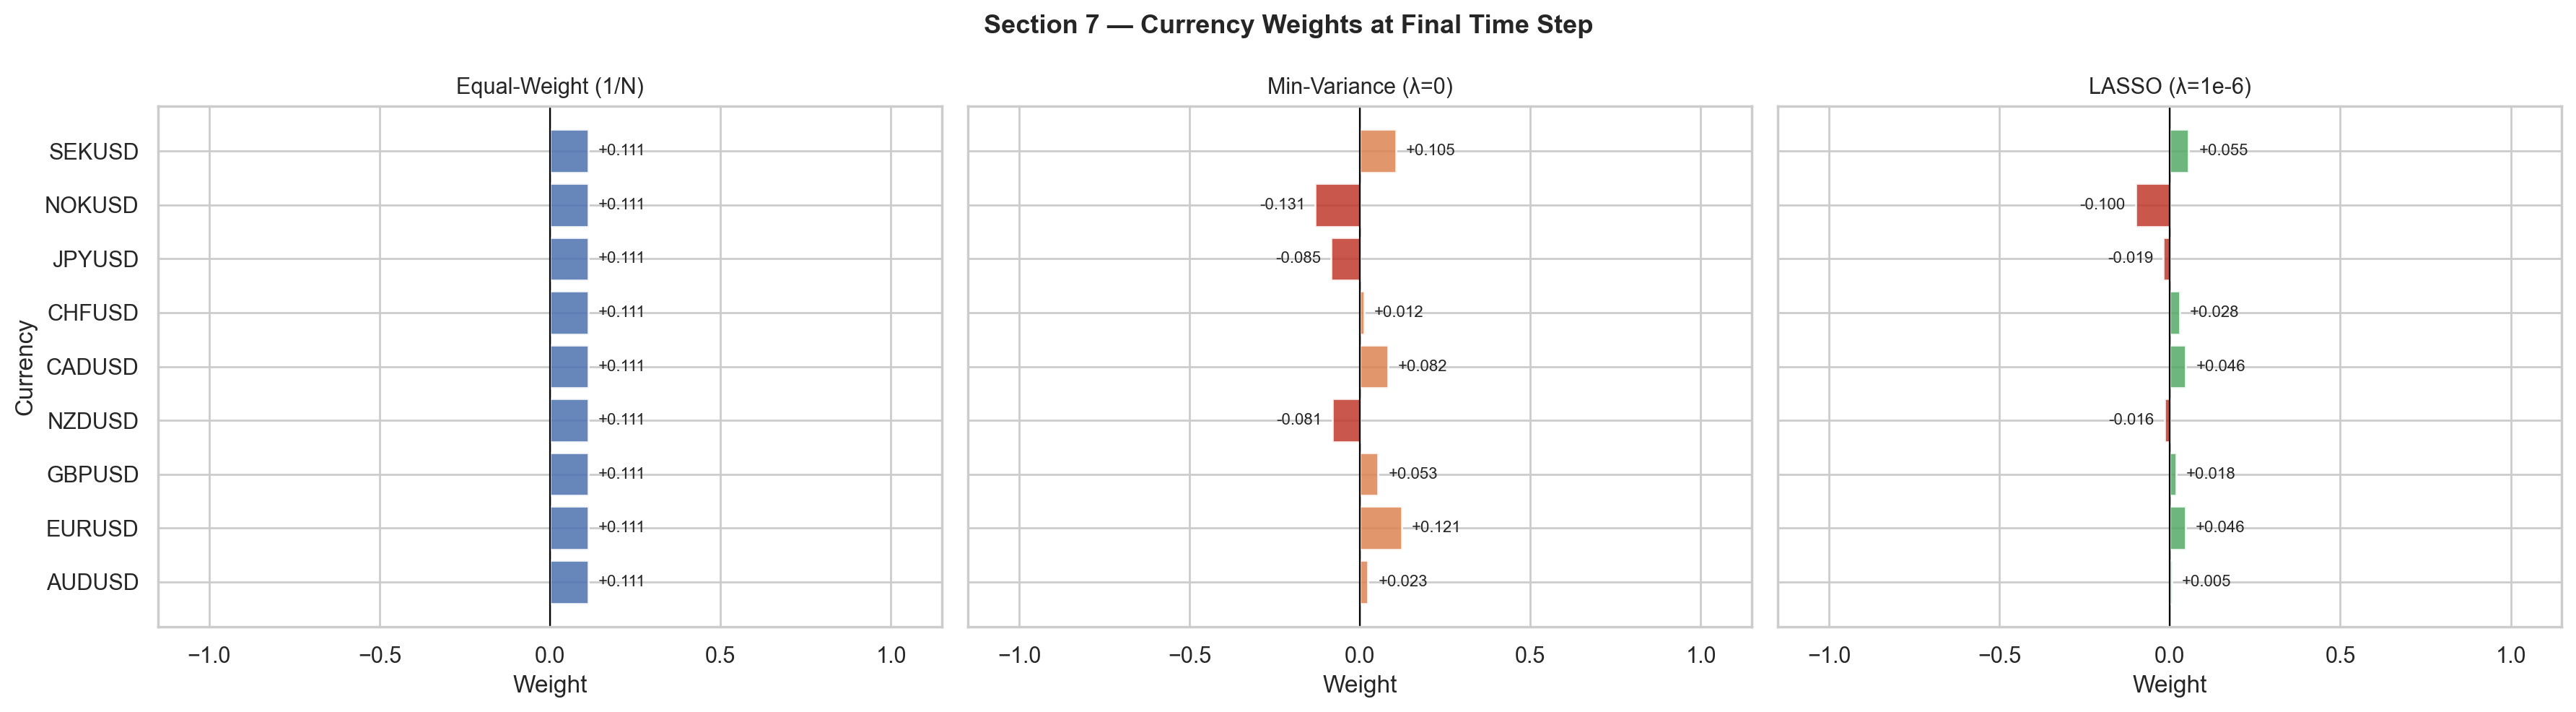

In [20]:
# ── Weights at the final time step ─────────────────────────────────────────────
ew_last    = ew_weights.iloc[-1]
mv_last    = mv_weights.iloc[-1].fillna(0)
lasso_last = lasso_weights.iloc[-1].fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

titles = ['Equal-Weight (1/N)', 'Min-Variance (\u03bb=0)', 'LASSO (\u03bb=1e-6)']
data   = [ew_last, mv_last, lasso_last]
base_c = [COLOURS['ew'], COLOURS['mv'], COLOURS['lasso']]

for ax, title, w, col in zip(axes, titles, data, base_c):
    bar_cols = [col if v >= 0 else '#C0392B' for v in w.values]
    ax.barh(CCY_COLS, w.values, color=bar_cols, alpha=0.85, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Weight')
    ax.set_xlim(-1.15, 1.15)
    for i, (ccy, val) in enumerate(zip(CCY_COLS, w.values)):
        ha = 'left' if val >= 0 else 'right'
        offset = 0.03 if val >= 0 else -0.03
        ax.text(val + offset, i, f'{val:+.3f}', va='center', ha=ha, fontsize=8)

axes[0].set_ylabel('Currency')
plt.suptitle('Section 7 — Currency Weights at Final Time Step', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()